In [1]:
# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns

# Loading data

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data clean up

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# cuz this date column was type str, now changed to type datetime

df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
# converting string formatted list to actual list

In [2]:
df_us = df[df['job_country'] == 'United States'].dropna(subset = ['salary_year_avg'])

In [3]:
job_titles = df_us['job_title_short'].value_counts().index[:6].tolist()

In [ ]:
df_us_top6 = df_us[df_us['job_title_short'].isin(job_titles)]

In [6]:
job_order = df_us_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending = False).index

Text(0, 0.5, ' ')

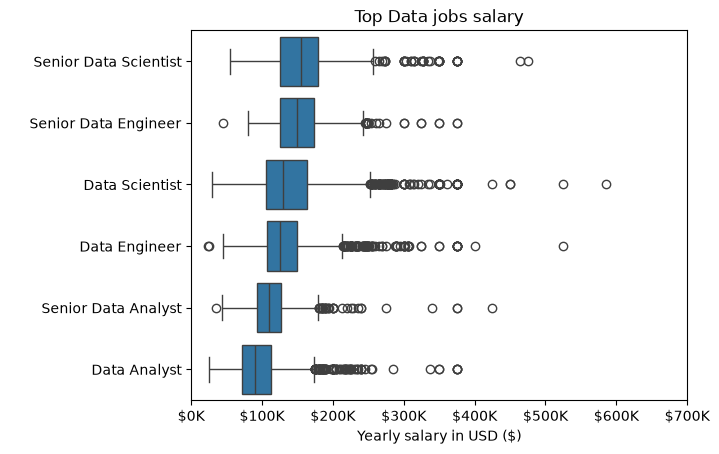

In [7]:
sns.boxplot(data = df_us_top6, x = 'salary_year_avg', y = 'job_title_short', order = job_order)

plt.title('Top Data jobs salary')
plt.xlabel('Yearly salary in USD ($)')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 700000)

plt.ylabel(" ")

In [10]:
df_us_da = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_us_da = df_us_da.dropna(subset = 'salary_year_avg')
df_us_da = df_us_da.explode('job_skills')

In [12]:
df_us_da[['salary_year_avg', 'job_skills']].head()

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [20]:
df_us_da_toppay = df_us_da.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values('median', ascending = False)
df_us_da_toppay = df_us_da_toppay.head(10)

In [21]:
df_us_da_skills = df_us_da.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values('count', ascending = False)
df_us_da_skills = df_us_da_skills.head(10).sort_values('median', ascending=False)

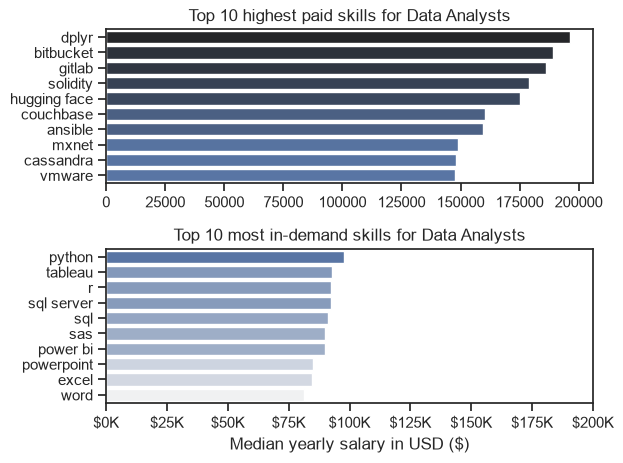

In [22]:
fig, ax = plt.subplots (2, 1)

sns.set_theme(style = 'ticks')
sns.barplot(data = df_us_da_toppay, x = 'median', y = df_us_da_toppay.index, ax= ax[0], hue = 'median', palette = 'dark:b_r')
ax[0].legend().remove()
ax[0].set_title('Top 10 highest paid skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0] = plt.gca()
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

sns.barplot(data = df_us_da_skills, x = 'median', y = df_us_da_skills.index, ax= ax[1], hue = 'median', palette = 'light:b')
ax[1].legend().remove()
ax[1].set_xlim(0, 200000)
ax[1].set_title('Top 10 most in-demand skills for Data Analysts')
ax[1].set_xlabel('Median yearly salary in USD ($)')
ax[1].set_ylabel('')
ax[1] = plt.gca()
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

fig.tight_layout()